# Exploratory Data Analysis

**Project:** R2 - Bike Sharing Demand

**Team:** Angelina Bautista & Molly Scally

**Date:** 2-10-2026




## Table of Contents
1. Setup & Load Data
2. Data Quality Check
3. Target Variable Analysis
4. Feature Distributions
5. Correlation Analysis
6. Key Findings Summary



## 1. Setup & Load Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded!")

✓ Libraries loaded!


In [2]:
# Load your data
# TODO: Update the file path to your dataset
df = pd.read_csv('../data/raw/hour.csv')

df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [3]:
print(f'The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset contains 17379 rows and 17 columns.


The dataset includes just over 17k rows. From the dataframe (and from the Kaggle data card) we know that the dataset spans a 2-year time period over the full years of 2011-2012. The columns include date/time features, aspects of the ambient environment, and bike usage numbers for each recorded hour. Each row corresponds to an hour of each day, thus we have data on 17,379 total hours. This is a little short of 2 years (17,520 + 24 for 2012's leap day = 17,544).  

The below code will do a quick check to see if hours without bike usage (where "cnt" = 0) were simply ommitted: 

In [4]:
print(f'there are {df.query("cnt == 0").shape[0]} instances where cnt = 0.')

there are 0 instances where cnt = 0.


So it's probably that the hours with zero rentals were just left out. The 165 missing hours could be important to address if we choose to do any serious time series modeling. The solution in that case would call for adding rows to complete the hourly grid, then imputing entries in the feature columns (e.g, in environment-related columns, forward-filling with the previous condition; placing zeroes in the count columns). We needn't worry about any of this until later.   

For EDA purposes, could further explore the missing rows by applying the grid to a copy of the original dataset. It might be interesting to see if they all occurred in big chunks or were randomly scattered over time. 

on-grid data has 17544 rows


<Axes: >

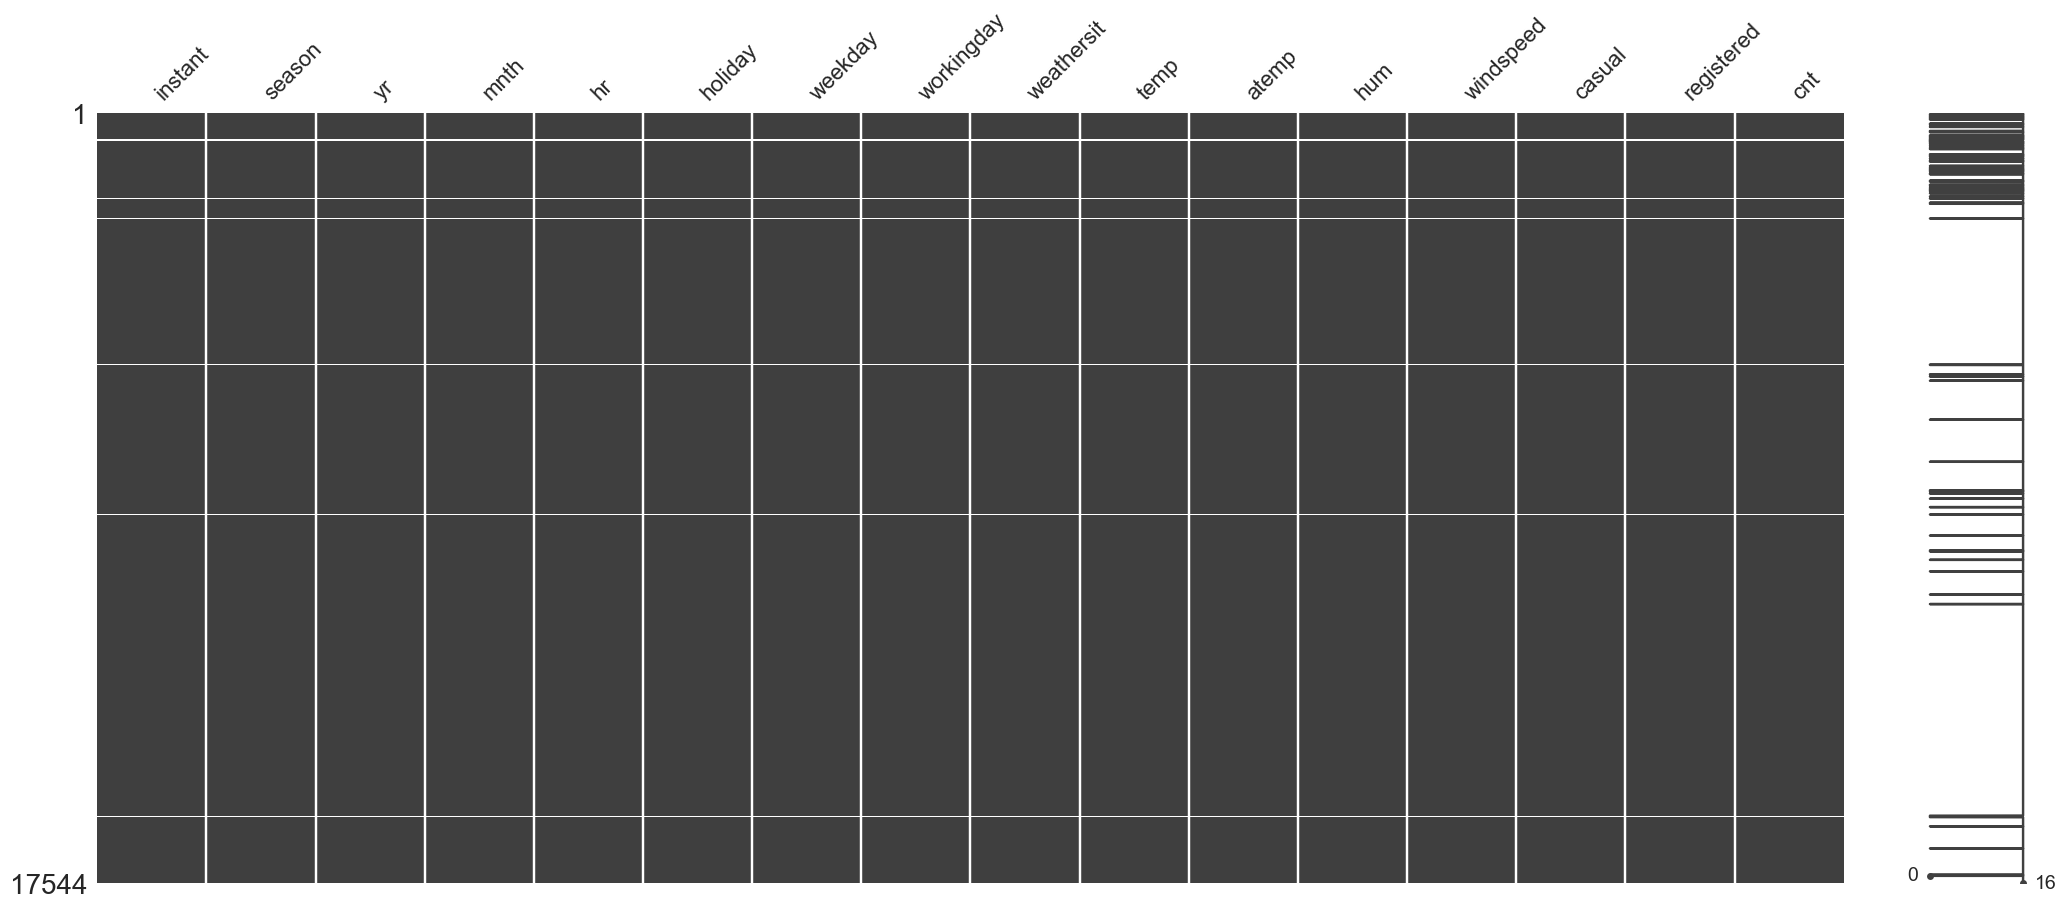

In [5]:
df_full_grid = df.copy()  # make copy of the original dataset 

# convert date column to date type and add the time according to `hr`
df_full_grid['dteday'] = pd.to_datetime(df_full_grid['dteday']) + pd.to_timedelta(df_full_grid['hr'], unit='h')

# create full grid of times
grid = pd.date_range(start=df_full_grid['dteday'].min(), end=df_full_grid['dteday'].max(), freq='h')

# apply grid and new nan rows
df_full_grid = df_full_grid.set_index('dteday').reindex(grid)

print(f'on-grid data has {df_full_grid.shape[0]} rows')

import missingno as msno
msno.matrix(df_full_grid)

In [6]:
for record in df_full_grid.index[df_full_grid['cnt'].isna()]:
    print(record)

2011-01-02 05:00:00
2011-01-03 02:00:00
2011-01-03 03:00:00
2011-01-04 03:00:00
2011-01-05 03:00:00
2011-01-06 03:00:00
2011-01-07 03:00:00
2011-01-11 03:00:00
2011-01-11 04:00:00
2011-01-12 03:00:00
2011-01-12 04:00:00
2011-01-14 04:00:00
2011-01-18 00:00:00
2011-01-18 01:00:00
2011-01-18 02:00:00
2011-01-18 03:00:00
2011-01-18 04:00:00
2011-01-18 05:00:00
2011-01-18 06:00:00
2011-01-18 07:00:00
2011-01-18 08:00:00
2011-01-18 09:00:00
2011-01-18 10:00:00
2011-01-18 11:00:00
2011-01-19 03:00:00
2011-01-22 05:00:00
2011-01-23 04:00:00
2011-01-24 02:00:00
2011-01-25 03:00:00
2011-01-26 03:00:00
2011-01-26 04:00:00
2011-01-26 18:00:00
2011-01-26 19:00:00
2011-01-26 20:00:00
2011-01-26 21:00:00
2011-01-26 22:00:00
2011-01-26 23:00:00
2011-01-27 00:00:00
2011-01-27 01:00:00
2011-01-27 02:00:00
2011-01-27 03:00:00
2011-01-27 04:00:00
2011-01-27 05:00:00
2011-01-27 06:00:00
2011-01-27 07:00:00
2011-01-27 08:00:00
2011-01-27 09:00:00
2011-01-27 10:00:00
2011-01-27 11:00:00
2011-01-27 12:00:00


If we look at the missing hours, we can see that most are events with multiple hours at a time being missing. It could totally be that these are due to disruptive extreme weather events or something.  

(the above isn't a permanant transformation of the data, and we can decide in the preprocessing step whether we want to incorporate the missing hours in some way.)


## 2. Data Quality Check

**Questions to answer:**
- What are the data types?
- Are there missing values?
- Are there duplicate rows?

In [7]:
print('Data type of each feature:')
df.dtypes

Data type of each feature:


instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [8]:
print(f'There are {df.isnull().sum().sum()} missing values in the dataset.')

There are 0 missing values in the dataset.


In [9]:
print(f'There are {df.duplicated().sum()} duplicate rows in the data.')

There are 0 duplicate rows in the data.


### Data Quality Observations

*TODO: Write your observations here*

1. **Data types:**   
- `int` datatype vars include: `instant`, `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`, `casual`, `registered`, and `cnt`.   
    - `instant` seems to be a unique identifier for each hourly record
    - `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, and `weathersit` are categorical, encoded to indicate certain things about the day. 
    - `casual`, `registered`, and `cnt` are counter variables for bike usage at the time. 
- a single `object` datatype variable: `dteday`  
- `float` datatype vars include: `temp`, `atemp`, `hum`, and `windspeed`  
2. **Missing values:** The data contains no missing values.
3. **Duplicates:** The data contains no duplicate entries.
4. **Potential issues:**   
- some of the names are relatively unintuitive. may change if desired
- dteday, the date column, is an `object` when it may need to be of `datetime` type  
- something to be aware of: multiple columns contain pre-encoded features. e.g., for `mnth`, we have levels 1, 2, ..., 12 instead of January, February, etc. Likewise, we have binary-encoded variables like `holiday` and `weekday` which only take on values 0 or 1. 
    - These are already of `int` data type; we should remember to treat these as qualitative variables during the EDA process.  
    - We will want to understand exactly how these are encoded during the EDA process and, if it would provide more clarity in our models, restructure the encoding scheme (later). That is, if we find out that one binary variable takes on values "1", "2" while others take on "0", "1", we may want to re-encode that odd one out. Or like in the cases of multi-level categorical variables like `mnth` or `weathersit` we will want to apply one-hot encoding or similar.  



## 3. Target Variable Analysis

**Your target variable:** We want to predict the number bikes being used (`cnt`). 

In [10]:
df['cnt'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

The mean bike count is approx. 189.5 bikes, with a median of 142 and standard deviation of 181.4 bikes. It ranges from 1 to 977. 

We can visualize this easily below: 

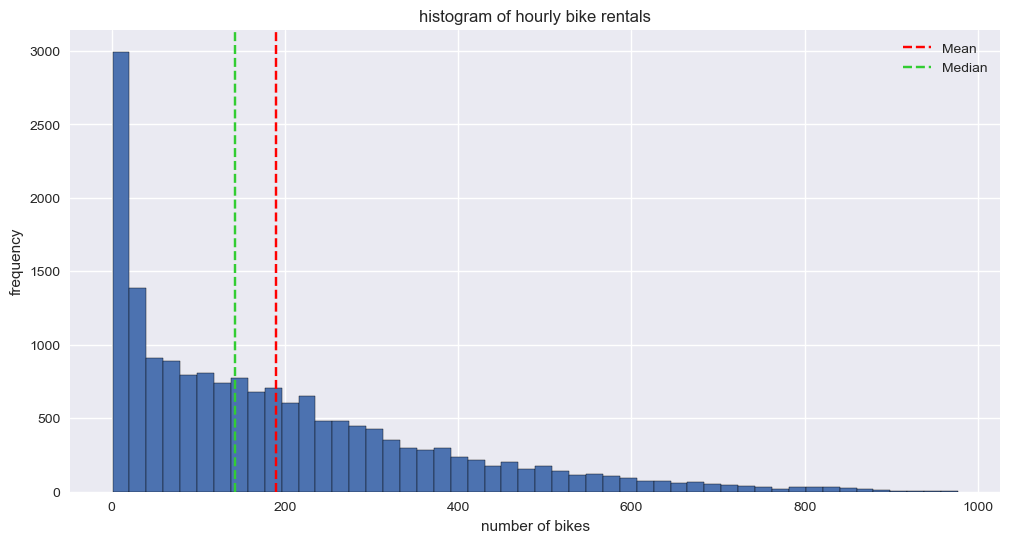

In [11]:
# plot histogram of target, bike count
plt.figure(figsize=(12,6)) 
plt.hist(df['cnt'], bins=50, edgecolor='black')  
plt.axvline(df['cnt'].mean(),color='red',linestyle='--',label='Mean')
plt.axvline(df['cnt'].median(),color='limegreen',linestyle='--',label='Median')
plt.xlabel('number of bikes')
plt.ylabel('frequency')  
plt.title('histogram of hourly bike rentals') 
plt.legend()
# plt.tight_layout() 
plt.show()  

Hourly bike rentals tend to occur in low numbers in the majority of cases, with fewer, rarer instances where large numbers of bikes are demanded. This makes the data follow a log distribution, and leads the overinflation in the mean, as it gets pushed up by high-count cases. We might anticipate applying a log transformation in a model. And we can preview it on a log scale in the below plot: 

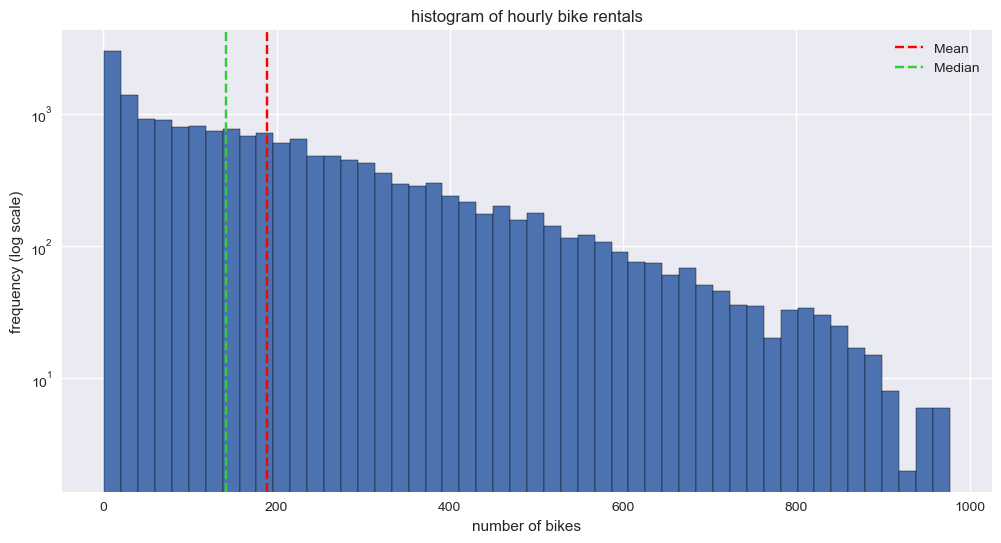

In [12]:
plt.figure(figsize=(12,6)) 
plt.hist(df['cnt'], bins=50, edgecolor='black')  
plt.axvline(df['cnt'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['cnt'].median(), color='limegreen', linestyle='--', label='Median')
plt.yscale('log') 
plt.xlabel('number of bikes')
plt.ylabel('frequency (log scale)')
plt.title('histogram of hourly bike rentals')
plt.legend()
plt.show()

With the transformed y-axis, we can see more clearly the relative differences in the number of hours where higher rental counts occurred. 

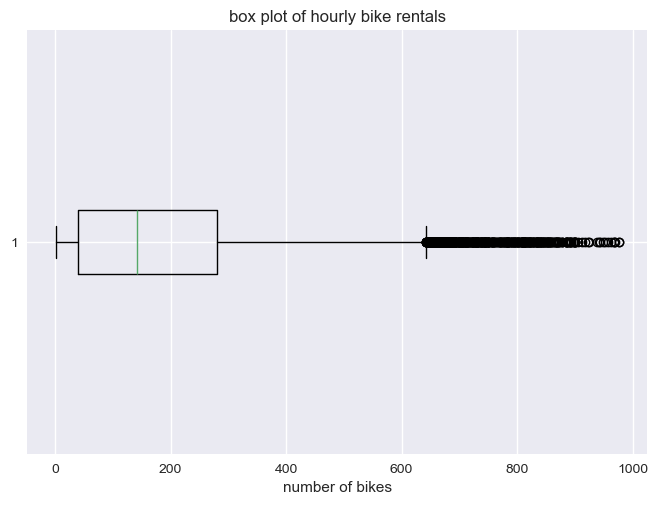

In [13]:
# boxplot of target variable
plt.plot(figsize=(6,4))
plt.boxplot(df['cnt'], vert=False)
plt.xlabel('number of bikes')
plt.title('box plot of hourly bike rentals')
plt.show()

For the majority of hours, rentals fall between 50 and just under 300 bikes (the 25th and 75th quartiles). But there are many extreme values on the upper end of the data: all of those points above the upper whisker. These could be considered outliers. These are probably real values that occur due to conditions being "just right" for rentals, like perfect weather/season/holiday status. 

### Target Variable Observations

*TODO: Write your observations here*

1. **Distribution shape:** Log
2. **Outliers:** many extreme points which could be considered outliers, even after log transformation of the target. They may likely be appropriate to keep as they may be legitimate datapoints and provide important information for the problem. We can scrutinize points more in the modeling phase by examining their leverage and influence. 
3. **Potential issues:** We may need to consider a log transformation of y and a review of points at the extreme upper end to see if they exert undue influence on model estimates.



## 4. Feature Distributions

As we saw above, we have one object feature: 

In [14]:
df.select_dtypes(include={'object'}).columns

Index(['dteday'], dtype='object')

And the rest are int or float. Some of those are to be thought of as numerical, while others categorical. 

In [15]:
print('all int and float dtype features:')
all_int_float_cols = df.drop(columns=['cnt', 'instant']).select_dtypes(include={'int', 'float'}).columns
print(all_int_float_cols)

print('\nof those, here are the truly numerical features:')
numerical_cols = df[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']].columns
print(numerical_cols)

print('\nand here are the categorical ones:')
categorical_cols = df[['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']].columns
print(categorical_cols)

print('\nand one feature, a unique identifier, which should probably be excluded from models: ')
id_col = df[['instant']].columns
print(id_col)

all int and float dtype features:
Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered'],
      dtype='object')

of those, here are the truly numerical features:
Index(['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered'], dtype='object')

and here are the categorical ones:
Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit'],
      dtype='object')

and one feature, a unique identifier, which should probably be excluded from models: 
Index(['instant'], dtype='object')


to be sure, we can confirm that `instant` is just a counter and wouldn't be meaningful for our problem: 

In [52]:
print(f"rows in df: {df.shape[0]}; unique of instant: {df['instant'].nunique()}")

print('\nfirst 5 rows:')
print(df['instant'].head())
print('\nlast 5 rows:')
print(df['instant'].tail())

rows in df: 17379; unique of instant: 17379

first 5 rows:
0    1
1    2
2    3
3    4
4    5
Name: instant, dtype: int64

last 5 rows:
17374    17375
17375    17376
17376    17377
17377    17378
17378    17379
Name: instant, dtype: int64


Here are the distributions for all features (exluding `cnt` and `instant`):

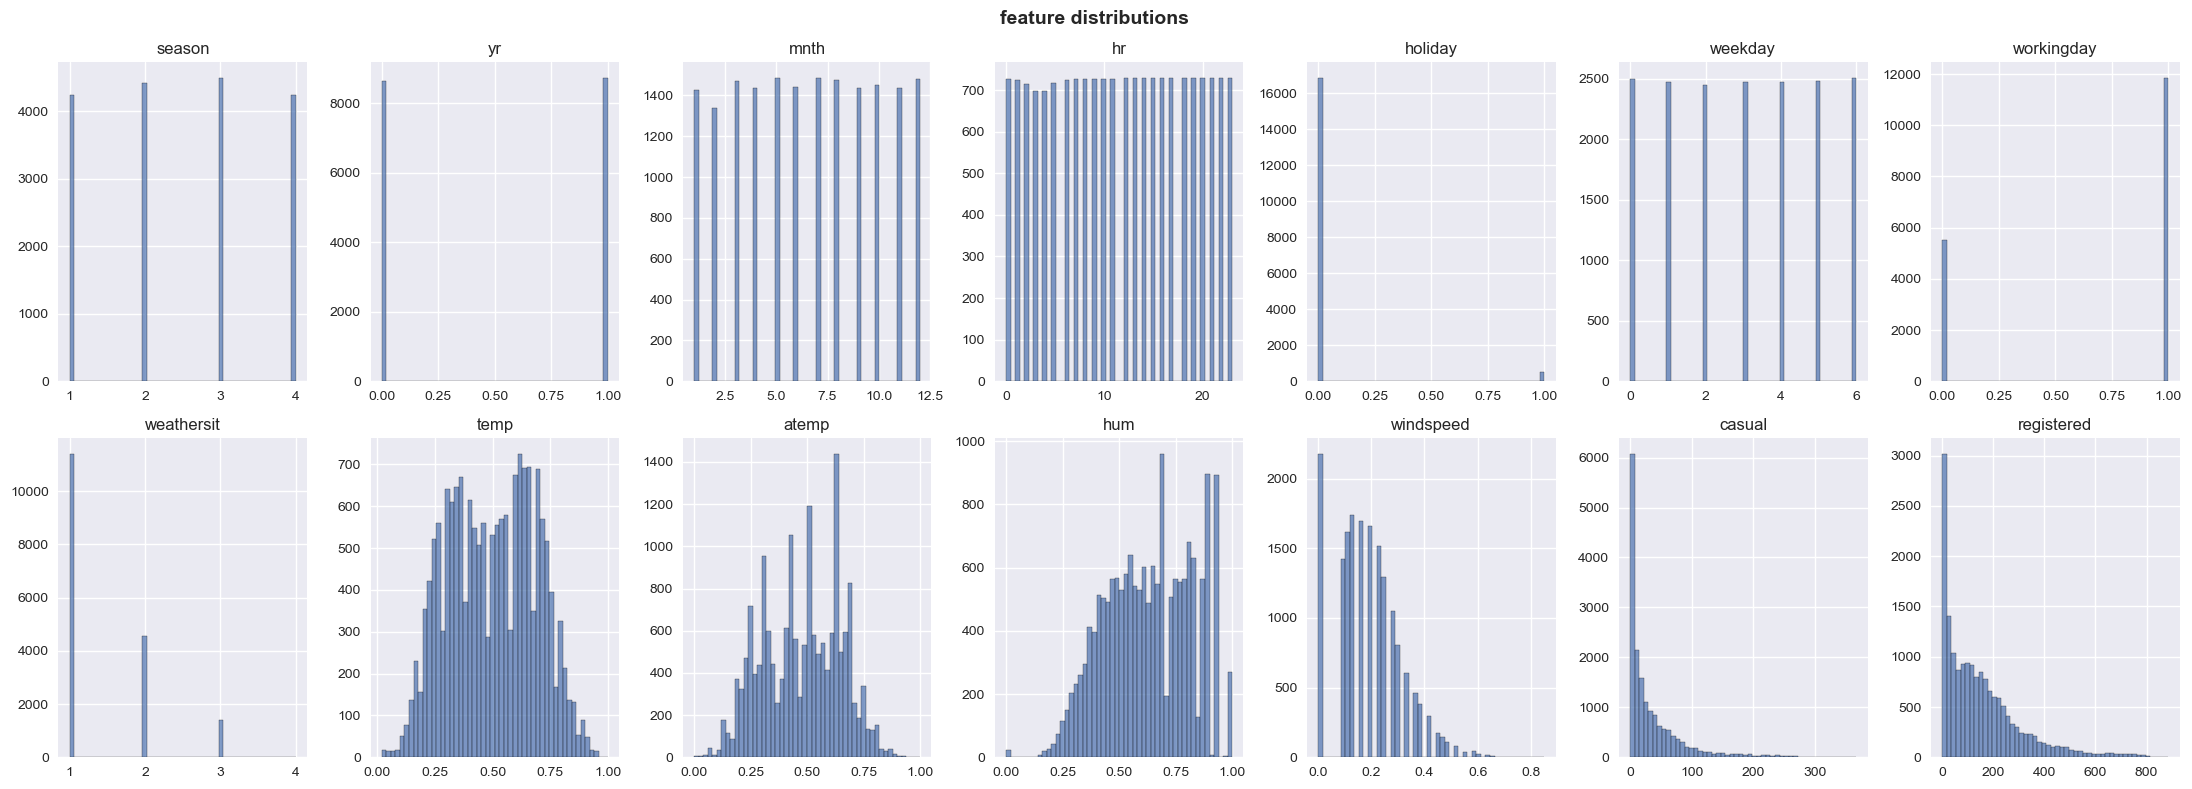

In [16]:
# histograms for all features
f, ax = plt.subplots(2, 7, figsize=(22, 8))
ax = ax.flatten()

for i, col in enumerate(all_int_float_cols):
    ax[i].hist( df[col], bins=50, edgecolor='black', alpha=0.7 )
    ax[i].set_title(col)
    ax[i].set_xlabel('')

plt.suptitle('feature distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Distribution Observations

*TODO: Write your observations here*

- `season`: there are slightly more observations in seasons 2 and 3 than in seasons 1 and 4 *note: by "observations", we mean "hours with a nonzero number of bike rentals". this impacts how we interpret these histograms: we know the dataset covers the entirety of two consecutive years on an hourly basis, with missing hours accounting for zero bike rentals. so having more observations in one class vs others for some categorical variable means that there are more hours with a nonzero number of bike rentals in that class vs others.*  
- `yr`: there are almost the same number of observations in both years of data. slightly fewer in 2012.  
- `mnth`: most nonzero days in months 1 and 2; clearly more rentals happening mid-year and steady even through December  
- `hr`: fewest observations in the early morning hours, but surprisingly steady throughout the rest of the day  
- `holiday`: relatively few datapoints occuring on holidays, which make sense. it might be interesting to see how holiday status might interact with other variables   
- `weekday`: weekend observations are most frequent, but appear only slightly more than weekdays  
- `workingday`: nearly twice as many obs  
- `weathersit`: we get a sense of how the weather impacts rentals. nicest weather in category 1, with most obseravtions by far. 
- `temp`: moderate temperatures in the middle of the extremes correspond to more rentals, but there is an interesting dip in the middle of the distribution  
- `atemp`: like temp, has a loose bell shape, but possibly some sparsity in middle region. 
- `hum`: looks like the drier conditions correspond to colder weather and wetter conditions corresond to the nicer weather. so rentals may be more agnostic to humidity than to temps.  
- `casual` and `registered` look a lot like our target (because they are components of it). since they are count variables, it is expected that they exhibit a log distribution  


## 5. Correlation Analysis

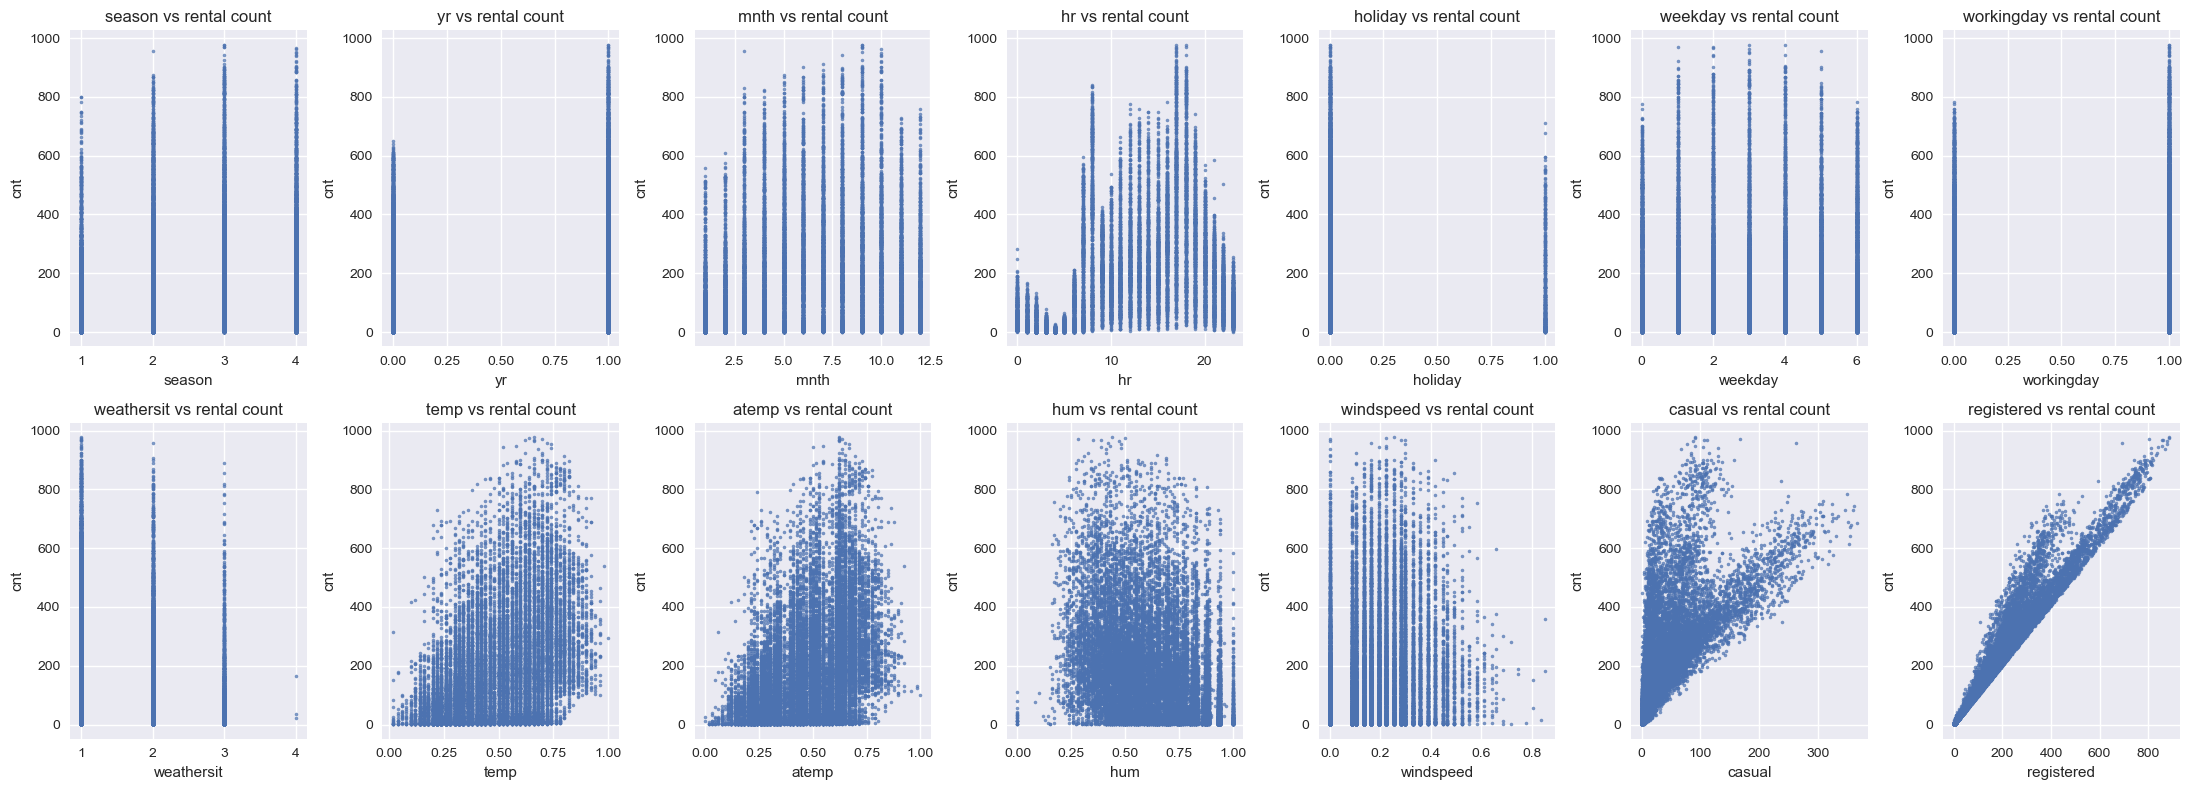

In [ ]:
# Scatter Plots (Features vs Target)
fig,axes = plt.subplots(2, 7, figsize=(22,8))
axes = axes.flatten()

for i,feature in enumerate(all_int_float_cols):
    
    axes[i].scatter(df[feature], df['cnt'], s=5, alpha=0.7)
    axes[i].set_title(f'{feature} vs rental count')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('cnt')

plt.tight_layout()
plt.show()

In [ ]:
# calculate correlation matrix
correlation_matrix = df.select_dtypes(include={'int', 'float'}).drop(columns=['instant']).corr()

In [ ]:
# display only the column with correlation coefficients between predictors and response 
correlation_matrix[['cnt']].round(3)

,cnt
season,0.178
yr,0.250
mnth,0.121
hr,0.394
holiday,-0.031
weekday,0.027
workingday,0.030
weathersit,-0.142
temp,0.405
atemp,0.401


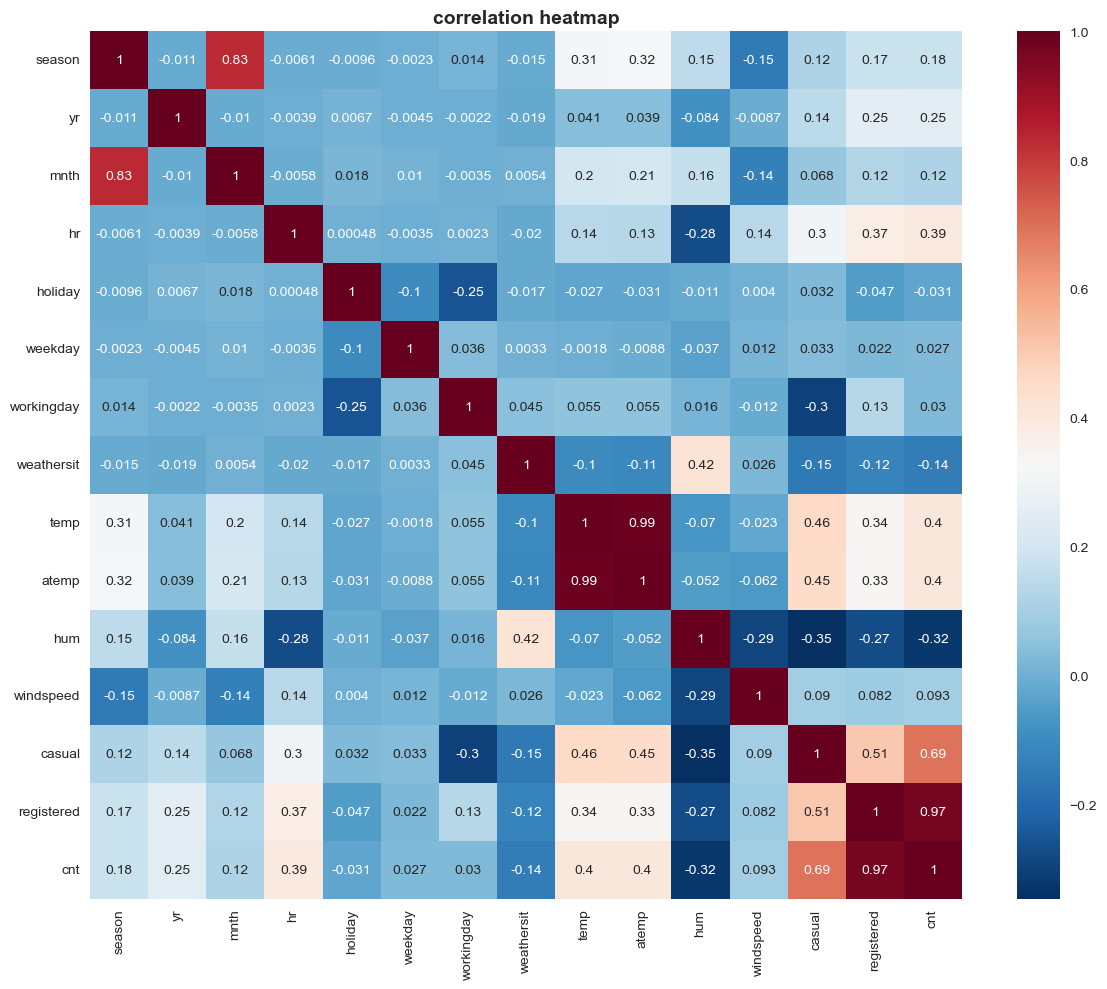

In [56]:
# display heatmap
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r') 
plt.title('correlation heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Observations

*TODO: Write your observations here*

1. **Strongest predictor:** 
- strongest predictor based both on appearence of scatterplot and correlation coefficients appears to be `temp` (r = 0.405) followed closely by `atemp` (r = 0.401). Temperature and bike rentals appear to rise together. 
- the count variables `casual` and `registered`  response. but it is misleading to think of these as possible predictors because they perfectly determine the response (overall count is their sum--a perfect linear combination of them).  
2. **Other important features:** 
- `hum` has a moderately negative relationship (r = -0.323): as humidity increases, bike rentals decrease. though its scatterplot lacks much distinct organization.   
- several of our categorical features could be helpful for the problem: 
    - the scatterplot for `weathersit` depicts a steady decrease in the bulk of rentals as weather level decreases, with a huge dropoff in rentals per hour at weather level 4. while not objectively strong, its correlation coefficient of r = -0.142 has more magnitude compared to other variables. this feature is not only categorical but ordinal (weather worsens by the level) which is corroborated by this r.  
    - from the scatterplot for `yr`, the average number of bikes rented per year appears higher in 2012 than 2011 (supported by r=0.250)
    - the scatterplot for `hr` alludes to the possibility of it as a useful factor.  
    - `weekday` and `workingday` are less clear, though there appears to be a slightly higher average of bike rentals on days in the 5-day work week. 
- from the correlation heatmap, we obviously see strong relationships between
- the count variables `casual` and `registered` are strongly related to the response according to their scatterplots and correlation coefficients (r=0.69 and 0.97), but are not valid predictors because their sum perfectly determines the response   
3. **Multicollinearity concerns:** 
- we may need to be wary of multicollinearity between `temp` and `atemp`-- r=0.99! this makes sense given the similarity of their scatterplots and the fact that they represent a very similar underlying thing (temperature).  
- variables `mnth` and `season` may need to be watched for redundancy; provide similar information and have r=0.83  
- during model-building, may want to experiment with dropping one of `holiday`, `workingday`, `weekday` to investigate usefulness  


## 6. Key Findings Summary

### Data quality
- 17379 rows × 17 columns  
- no missing values  
- no duplicate rows  
- clean dataset ready for next steps  

### important discoveries


### 

## EDA Checklist

Before moving to modeling, ensure you've completed:

- [x] Loaded and examined the data
- [x] Checked data types
- [x] Identified and documented missing values
- [x] Analyzed target variable distribution
- [x] Examined feature distributions
- [x] Created correlation analysis
- [x] Documented key findings
- [x] Identified potential data quality issues